# A Multi-Objective AutoML-based Efficient Intrusion Detection System for EV Charging Networks
This is the code for the paper entitled "**A Multi-Objective AutoML-based Efficient Intrusion Detection System for EV Charging Networks**" accepted in 2026 IEEE Global Communications Conference (GLOBECOM).  
Authors: Li Yang (liyanghart@gmail.com)  
Organization: The Advanced Networking Technology and Security (ANTS) Lab, Faculty of Business and IT, Ontario Tech University, Ontario, Canada

If you find this repository useful in your research, please cite:  
L. Yang, “A Multi-Objective AutoML-based Efficient Intrusion Detection System for EV Charging Networks," GLOBECOM 2026 - 2026 IEEE Global Communications Conference, 2026, Macau S.A.R., China, pp. 1-6.

## Import libraries

In [1]:
# Suppress non-critical warnings to keep notebook output concise.
import warnings
warnings.filterwarnings("ignore")

# Core data handling and visualization libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting, evaluation metrics, and baseline classifiers.
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score, precision_recall_fscore_support
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# Gradient-boosting libraries and general experiment utilities.
import lightgbm as lgb
import xgboost as xgb
import joblib
import os
import time

# Encode categorical class labels when required by the dataset.
from sklearn.preprocessing import LabelEncoder


## Read the CICIDS2017 dataset

In [2]:
# Load the preprocessed CICIDS2017 files from the Data directory.
# Uncomment the training-data line only when rebuilding the sampled training set.
training_data = pd.read_csv("Data/CICIDS2017_training_set.csv")
testing_data = pd.read_csv("Data/CICIDS2017_test_set.csv")

In [3]:
# Preview the training dataframe to verify its columns and loaded values.
training_data

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,1.606726,0.084889,0.090843,1.199539,0.006148,2.147842,-0.310140,0.610119,0.964657,0.281114,...,0.002556,7.329569,-0.104565,4.564450,8.278075,2.124166,-0.10946,2.044352,2.165361,0
1,-0.433246,-0.000482,-0.000395,0.001070,-0.005395,-0.009203,-0.310140,0.021604,0.036820,1.001430,...,0.002545,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0
2,-0.439345,-0.011153,-0.009418,-0.054365,-0.007139,-0.281099,-0.210703,-0.280518,-0.245069,-0.444340,...,0.002545,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0
3,-0.439345,-0.011153,-0.009418,-0.054965,-0.007142,-0.289465,-0.310140,-0.312760,-0.245069,-0.447423,...,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0
4,-0.433179,-0.011153,-0.009418,-0.050563,-0.007109,-0.228114,0.419069,-0.076317,-0.245069,-0.409403,...,0.002545,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2264589,-0.439341,-0.009819,-0.008416,-0.050363,-0.007122,-0.257395,0.071037,-0.189165,-0.245069,-0.435606,...,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0
2264590,-0.437259,-0.007151,-0.008416,-0.039756,-0.007071,-0.236480,0.319631,-0.108559,-0.245069,-0.406321,...,0.002545,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0
2264591,-0.439341,-0.009819,-0.010421,-0.053765,-0.007142,-0.281099,-0.210703,-0.280518,-0.245069,-0.447423,...,0.002545,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0
2264592,-0.437903,-0.011153,-0.009418,-0.046160,-0.007089,-0.166763,1.148278,0.160126,-0.245069,-0.385770,...,0.002556,-0.125734,-0.104565,-0.149326,-0.101016,-0.351926,-0.10946,-0.356868,-0.338993,0


In [4]:
# Inspect the original class distribution before constructing the sampled training set.
training_data.Label.value_counts()

Label
0    1818477
3     304559
5     127144
2      11068
6       1744
1       1573
4         29
Name: count, dtype: int64

In [5]:
# Keep every class with fewer than 10,000 samples and sample 2% from larger classes.
# Count samples in each class before applying the class-aware sampling rule
class_counts = training_data['Label'].value_counts()
# Determine the retained sample count for each class
samples_to_keep = class_counts.apply(
    lambda x: x if x < 10000 else int(x * 0.02)
)
# Draw reproducible samples independently within each class
balanced_training_data = training_data.groupby('Label').apply(lambda x: x.sample(n=samples_to_keep[x.name], random_state=42)).reset_index(drop=True)
# Separate the sampled training data into features and labels
X_train = balanced_training_data.drop(columns=['Label'])
y_train = balanced_training_data['Label']

# Keep the complete test data separate for final evaluation
X_test = testing_data.drop(columns=['Label'])
y_test = testing_data['Label']


In [6]:
# Optionally save the sampled training set once so later runs can load it directly
# balanced_training_data.to_csv("Data/CICIDS2017_training_set_0.02.csv", index=False)

# Load the previously generated sampled training set
balanced_training_data = pd.read_csv("Data/CICIDS2017_training_set_0.02.csv")
X_train = balanced_training_data.drop(columns=['Label'])
y_train = balanced_training_data['Label']

# Separate the complete test set into features and labels
X_test = testing_data.drop(columns=['Label'])
y_test = testing_data['Label']



In [7]:
# Verify the class distribution in the sampled training labels.
y_train.value_counts()

Label
0    36369
3     6091
5     2542
6     1744
1     1573
2      221
4       29
Name: count, dtype: int64

# Baseline Machine Learning Models

In [8]:
# Evaluate this baseline using the original training/test data and reporting procedure.
import time
import pickle
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    classification_report
)


def p99_latency_ms(model, X, n_repeats=30):
    _ = model.predict(X)  # Warm up the prediction path before timing.

    # Repeat batch predictions and convert each run to milliseconds per sample.
    latencies = []
    for _ in range(n_repeats):
        start = time.perf_counter()
        _ = model.predict(X)
        end = time.perf_counter()
        latencies.append((end - start) / len(X) * 1000)

    return np.percentile(latencies, 99)


# Estimate the serialized model footprint in megabytes.
def model_size_mb(model):
    return len(pickle.dumps(model)) / (1024 ** 2)


# ============================================================
# Random Forest model
# ============================================================

model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

# Train the model and record elapsed wall-clock time.
start = time.perf_counter()
model.fit(X_train, y_train)
training_time = time.perf_counter() - start

# Generate test predictions and measure average inference time.
start = time.perf_counter()
y_pred = model.predict(X_test)
testing_time = time.perf_counter() - start

testing_time_ms_per_sample = testing_time / len(X_test) * 1000

# Compute detection-effectiveness and deployment-efficiency metrics.
accuracy = accuracy_score(y_test, y_pred)

precision, recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

p99_latency = p99_latency_ms(model, X_test, n_repeats=30)
size_mb = model_size_mb(model)

# Report aggregate metrics followed by class-level diagnostics.
print("Training time seconds:", training_time)
print("Testing time ms per sample:", testing_time_ms_per_sample)
print("P99 inference latency ms per sample:", p99_latency)
print("Model size MB:", size_mb)

print("Accuracy: %.3f%%" % (accuracy * 100))
print("Precision: %.3f%%" % (precision * 100))
print("Recall: %.3f%%" % (recall * 100))
print("Weighted F1 Score: %.3f%%" % (weighted_f1 * 100))
print("Macro F1 Score: %.3f%%" % (macro_f1 * 100))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

Training time seconds: 0.3256326999999146
Testing time ms per sample: 0.0010411582463262514
P99 inference latency ms per sample: 0.0009072589159404188
Model size MB: 5.407619476318359
Accuracy: 99.689%
Precision: 99.713%
Recall: 99.689%
Weighted F1 Score: 99.696%
Macro F1 Score: 89.870%

Confusion matrix:
[[453529    295      3    536      6    194     57]
 [     7    386      0      0      0      0      0]
 [   158      0   2607      2      0      0      0]
 [   437      2      0  75698      0      2      1]
 [     0      0      0      0      7      0      0]
 [    17      0      0     26      0  31740      3]
 [    15      0      0      1      0      0    420]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454620
           1       0.57      0.98      0.72       393
           2       1.00      0.94      0.97      2767
           3       0.99      0.99      0.99     76140
           4       0.54      1.00

In [9]:
# Evaluate this baseline using the original training/test data and reporting procedure.
import time
import numpy as np
import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    classification_report
)


def p99_latency_ms(model, X, n_repeats=30):
    _ = model.predict(X)  # Warm up the prediction path before timing.

    # Repeat batch predictions and convert each run to milliseconds per sample.
    latencies = []
    for _ in range(n_repeats):
        start = time.perf_counter()
        _ = model.predict(X)
        end = time.perf_counter()
        latencies.append((end - start) / len(X) * 1000)

    return np.percentile(latencies, 99)


# Measure the LightGBM booster size and include stored feature names when available.
def lgbm_model_size_mb(model, X=None):
    model_bytes = len(model.booster_.model_to_string().encode("utf-8"))

    feature_bytes = 0
    if X is not None and hasattr(X, "columns"):
        feature_text = "\n".join([str(c) for c in X.columns])
        feature_bytes = len(feature_text.encode("utf-8"))

    return (model_bytes + feature_bytes) / (1024 ** 2)


# ============================================================
# LightGBM model
# ============================================================

model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Train the model and record elapsed wall-clock time.
start = time.perf_counter()
model.fit(X_train, y_train)
training_time = time.perf_counter() - start

# Generate test predictions and measure average inference time.
start = time.perf_counter()
y_pred = model.predict(X_test)
testing_time = time.perf_counter() - start

testing_time_ms_per_sample = testing_time / len(X_test) * 1000

# Compute detection-effectiveness and deployment-efficiency metrics.
accuracy = accuracy_score(y_test, y_pred)

precision, recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

p99_latency = p99_latency_ms(model, X_test, n_repeats=30)
size_mb = lgbm_model_size_mb(model, X_train)

# Report aggregate metrics followed by class-level diagnostics.
print("Training time seconds:", training_time)
print("Testing time ms per sample:", testing_time_ms_per_sample)
print("P99 inference latency ms per sample:", p99_latency)
print("Model size MB:", size_mb)

print("Accuracy: %.3f%%" % (accuracy * 100))
print("Precision: %.3f%%" % (precision * 100))
print("Recall: %.3f%%" % (recall * 100))
print("Weighted F1 Score: %.3f%%" % (weighted_f1 * 100))
print("Macro F1 Score: %.3f%%" % (macro_f1 * 100))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

Training time seconds: 1.32907349999914
Testing time ms per sample: 0.0009584118315133452
P99 inference latency ms per sample: 0.0010268554938705106
Model size MB: 2.369696617126465
Accuracy: 99.805%
Precision: 99.836%
Recall: 99.805%
Weighted F1 Score: 99.816%
Macro F1 Score: 84.260%

Confusion matrix:
[[453813    305      2    245     48    191     16]
 [     3    390      0      0      0      0      0]
 [    39      0   2723      0      0      4      1]
 [   198      0      0  75931      0      8      3]
 [     0      0      0      0      7      0      0]
 [    19      0      0     18      0  31747      2]
 [     3      0      0      0      0      0    433]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454620
           1       0.56      0.99      0.72       393
           2       1.00      0.98      0.99      2767
           3       1.00      1.00      1.00     76140
           4       0.13      1.00  

In [10]:
# Evaluate this baseline using the original training/test data and reporting procedure.
import time
import numpy as np
import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    classification_report
)


def p99_latency_ms(model, X, n_repeats=30):
    _ = model.predict(X)  # Warm up the prediction path before timing.

    # Repeat batch predictions and convert each run to milliseconds per sample.
    latencies = []
    for _ in range(n_repeats):
        start = time.perf_counter()
        _ = model.predict(X)
        end = time.perf_counter()
        latencies.append((end - start) / len(X) * 1000)

    return np.percentile(latencies, 99)


# Measure the LightGBM booster size and include stored feature names when available.
def lgbm_model_size_mb(model, X=None):
    model_bytes = len(model.booster_.model_to_string().encode("utf-8"))

    feature_bytes = 0
    if X is not None and hasattr(X, "columns"):
        feature_text = "\n".join([str(c) for c in X.columns])
        feature_bytes = len(feature_text.encode("utf-8"))

    return (model_bytes + feature_bytes) / (1024 ** 2)


# ============================================================
# LightGBM model
# ============================================================

model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Train the model and record elapsed wall-clock time.
start = time.perf_counter()
model.fit(X_train, y_train)
training_time = time.perf_counter() - start

# Generate test predictions and measure average inference time.
start = time.perf_counter()
y_pred = model.predict(X_test)
testing_time = time.perf_counter() - start

testing_time_ms_per_sample = testing_time / len(X_test) * 1000

# Compute detection-effectiveness and deployment-efficiency metrics.
accuracy = accuracy_score(y_test, y_pred)

precision, recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

p99_latency = p99_latency_ms(model, X_test, n_repeats=30)
size_mb = lgbm_model_size_mb(model, X_train)

# Report aggregate metrics followed by class-level diagnostics.
print("Training time seconds:", training_time)
print("Testing time ms per sample:", testing_time_ms_per_sample)
print("P99 inference latency ms per sample:", p99_latency)
print("Model size MB:", size_mb)

print("Accuracy: %.3f%%" % (accuracy * 100))
print("Precision: %.3f%%" % (precision * 100))
print("Recall: %.3f%%" % (recall * 100))
print("Weighted F1 Score: %.3f%%" % (weighted_f1 * 100))
print("Macro F1 Score: %.3f%%" % (macro_f1 * 100))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

Training time seconds: 1.2959453999992547
Testing time ms per sample: 0.0008295074264902342
P99 inference latency ms per sample: 0.001017715536016779
Model size MB: 2.3607263565063477
Accuracy: 99.548%
Precision: 99.571%
Recall: 99.548%
Weighted F1 Score: 99.554%
Macro F1 Score: 92.563%

Confusion matrix:
[[453635    291      0    499      1    191      3]
 [     6    387      0      0      0      0      0]
 [   306      0   2459      2      0      0      0]
 [   990      0      0  75079      0      0     71]
 [     0      0      0      0      7      0      0]
 [   167      0      0     12      0  31605      2]
 [    15      0      0      1      0      0    420]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454620
           1       0.57      0.98      0.72       393
           2       1.00      0.89      0.94      2767
           3       0.99      0.99      0.99     76140
           4       0.88      1.00

In [11]:
# Evaluate this baseline using the original training/test data and reporting procedure.
import time
import numpy as np
import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    classification_report
)


def p99_latency_ms(model, X, n_repeats=30):
    _ = model.predict(X)  # Warm up the prediction path before timing.

    # Repeat batch predictions and convert each run to milliseconds per sample.
    latencies = []
    for _ in range(n_repeats):
        start = time.perf_counter()
        _ = model.predict(X)
        end = time.perf_counter()
        latencies.append((end - start) / len(X) * 1000)

    return np.percentile(latencies, 99)


# Measure the LightGBM booster size and include stored feature names when available.
def lgbm_model_size_mb(model, X=None):
    model_bytes = len(model.booster_.model_to_string().encode("utf-8"))

    feature_bytes = 0
    if X is not None and hasattr(X, "columns"):
        feature_text = "\n".join([str(c) for c in X.columns])
        feature_bytes = len(feature_text.encode("utf-8"))

    return (model_bytes + feature_bytes) / (1024 ** 2)


# ============================================================
# LightGBM model
# ============================================================

model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.03,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Train the model and record elapsed wall-clock time.
start = time.perf_counter()
model.fit(X_train, y_train)
training_time = time.perf_counter() - start

# Generate test predictions and measure average inference time.
start = time.perf_counter()
y_pred = model.predict(X_test)
testing_time = time.perf_counter() - start

testing_time_ms_per_sample = testing_time / len(X_test) * 1000

# Compute detection-effectiveness and deployment-efficiency metrics.
accuracy = accuracy_score(y_test, y_pred)

precision, recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

p99_latency = p99_latency_ms(model, X_test, n_repeats=30)
size_mb = lgbm_model_size_mb(model, X_train)

# Report aggregate metrics followed by class-level diagnostics.
print("Training time seconds:", training_time)
print("Testing time ms per sample:", testing_time_ms_per_sample)
print("P99 inference latency ms per sample:", p99_latency)
print("Model size MB:", size_mb)

print("Accuracy: %.3f%%" % (accuracy * 100))
print("Precision: %.3f%%" % (precision * 100))
print("Recall: %.3f%%" % (recall * 100))
print("Weighted F1 Score: %.3f%%" % (weighted_f1 * 100))
print("Macro F1 Score: %.3f%%" % (macro_f1 * 100))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

Training time seconds: 1.348590100000365
Testing time ms per sample: 0.0010494512928570941
P99 inference latency ms per sample: 0.0011257400595956733
Model size MB: 2.3521223068237305
Accuracy: 99.788%
Precision: 99.815%
Recall: 99.788%
Weighted F1 Score: 99.797%
Macro F1 Score: 87.812%

Confusion matrix:
[[453726    310      0    357     15    193     19]
 [     4    389      0      0      0      0      0]
 [    40      0   2723      0      0      4      0]
 [   204      0      0  75931      0      3      2]
 [     0      0      0      0      7      0      0]
 [    22      0      0     18      0  31744      2]
 [     5      0      0      0      0      0    431]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454620
           1       0.56      0.99      0.71       393
           2       1.00      0.98      0.99      2767
           3       1.00      1.00      1.00     76140
           4       0.32      1.00

# MOO IDS

Training shape: (48569, 77)
Test shape: (566149, 77)
Actual CV folds: 3

Feature importance ranking:
                    feature  importance  relative_importance  \
0    Init_Win_bytes_forward      3116.0             0.148409   
1   Init_Win_bytes_backward      2050.0             0.097638   
2             Flow Duration      1583.0             0.075395   
3              Flow IAT Min      1511.0             0.071966   
4               Fwd IAT Min      1078.0             0.051343   
..                      ...         ...                  ...   
72        Fwd Avg Bulk Rate         0.0             0.000000   
73      Subflow Fwd Packets         0.0             0.000000   
74        Subflow Fwd Bytes         0.0             0.000000   
75      Subflow Bwd Packets         0.0             0.000000   
76        Subflow Bwd Bytes         0.0             0.000000   

    cumulative_relative_importance  
0                         0.148409  
1                         0.246047  
2                  

[I 2026-08-03 13:19:02,734] A new study created in memory with name: LightGBM_NSGAIII_MOO_IDS_F1_Prioritized



Cross validated baseline:
weighted_f1_mean : 0.9939207645566924
weighted_f1_std : 0.0030878435069567516
weighted_f1_robust : 0.993303195855301
p99_latency_ms_median : 0.0012835336627529516
p99_latency_ms_mean : 0.001273011597781238
model_size_bytes_mean : 2482039.0
model_size_mb_mean : 2.3670568466186523
p99_latency_ratio : 1.0
model_size_ratio : 1.0


  2%|▏         | 1/50 [00:03<03:12,  3.92s/it]

[I 2026-08-03 13:19:06,582] Trial 0 finished with values: [0.9962831511722423, 0.9065219598603296, 0.9155024021244897] and parameters: {'target_importance': 1.0, 'max_depth': -1, 'num_leaves': 31, 'n_estimators': 100, 'learning_rate': 0.05, 'min_child_samples': 20, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_lambda': 0.0001}.


...

[I 2026-08-03 13:21:52,415] Trial 47 finished with values: [0.9966616063705922, 1.584350838183846, 0.7129965860058336] and parameters: {'target_importance': 0.8309198091010609, 'max_depth': 6, 'num_leaves': 15, 'n_estimators': 150, 'learning_rate': 0.037563022244566494, 'min_child_samples': 17, 'subsample': 0.8009812834581761, 'colsample_bytree': 0.7403244030816922, 'reg_lambda': 0.0002074315690122004}.


 98%|█████████▊| 49/50 [02:52<00:03,  3.09s/it]

[I 2026-08-03 13:21:54,684] Trial 48 finished with values: [0.9966509602903946, 0.9471877478702362, 0.2757637302771364] and parameters: {'target_importance': 0.9974900580974864, 'max_depth': 3, 'num_leaves': 30, 'n_estimators': 120, 'learning_rate': 0.10072340993041301, 'min_child_samples': 127, 'subsample': 0.9895080731999537, 'colsample_bytree': 0.7372891670456634, 'reg_lambda': 0.45116705169708454}.


100%|██████████| 50/50 [02:54<00:00,  3.48s/it]


[I 2026-08-03 13:21:56,705] Trial 49 finished with values: [0.9872033722839237, 0.6884036455472063, 0.40304268654387243] and parameters: {'target_importance': 0.9845851142052595, 'max_depth': 6, 'num_leaves': 18, 'n_estimators': 80, 'learning_rate': 0.01504085652356894, 'min_child_samples': 124, 'subsample': 0.89955916620886, 'colsample_bytree': 0.8569196274307358, 'reg_lambda': 0.006225187269045145}.

Final Pareto front solutions:
    trial_number  weighted_f1_robust  weighted_f1_mean  weighted_f1_std  \
0             24            0.995570          0.995684         0.000570   
1             48            0.996651          0.996704         0.000265   
2              0            0.996283          0.996300         0.000086   
3             16            0.996997          0.997059         0.000309   
4             47            0.996662          0.996706         0.000223   
5              5            0.997029          0.997071         0.000212   
6              2            0.997201   

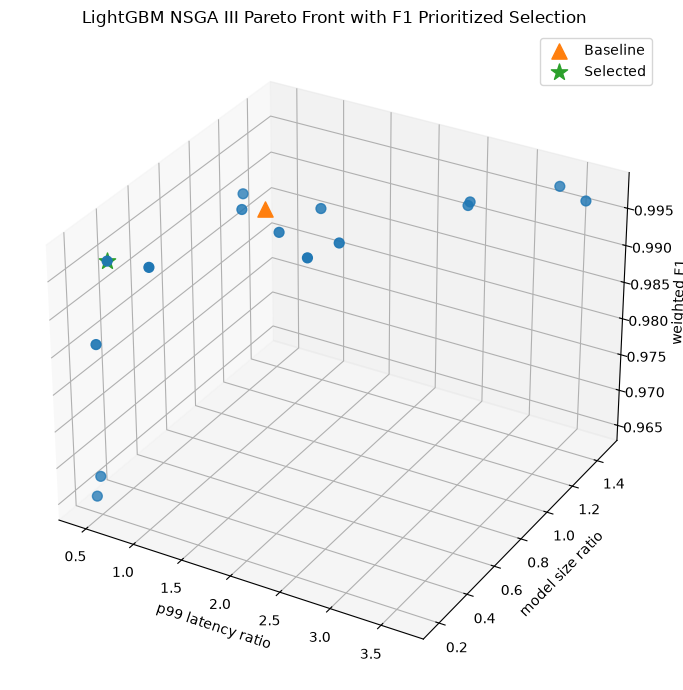

In [ ]:
# ============================================================
# Robust LightGBM MOO IDS
# Optuna NSGA III
#
# Objectives:
#   1. Maximize weighted F1
#   2. Minimize p99 latency ratio
#   3. Minimize model size ratio
#
# Main changes:
#   1. Only important LightGBM hyperparameters are tuned
#   2. No macro F1 is mixed into the F1 objective
#   3. Final Pareto selection uses high F1 weight
#   4. p99 latency and model size have lower weights
#   5. Cross validation is used during MOO search
# ============================================================

# Import runtime, optimization, modeling, and evaluation dependencies.
import time
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import optuna

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score as sk_f1_score,
    confusion_matrix,
    classification_report
)

np.random.seed(42)


# ============================================================
# 0. Settings
# ============================================================

N_TRIALS = 50
N_SPLITS = 3

LATENCY_REPEATS_CV = 3
LATENCY_REPEATS_FINAL = 30
LATENCY_EVAL_MAX_SAMPLES = 50000

MAX_RATIO_CAP = 10.0

# Higher F1 priority
UTILITY_WEIGHTS = {
    "f1": 0.95,
    "latency": 0.03,
    "size": 0.02
}

# Larger budget means a small F1 loss can be tolerated only if efficiency gains are meaningful
F1_LOSS_BUDGET = 0.010

# Hard safety filter before utility selection
MAX_ALLOWED_WEIGHTED_F1_DROP = 0.003

# Set True only if you want to force baseline when final test utility is lower
ENABLE_FINAL_FALLBACK = False


# ============================================================
# 1. Utility functions
# ============================================================

# Standardize feature inputs as DataFrames while preserving column names.
def ensure_dataframe(X, reference_columns=None):
    if isinstance(X, pd.DataFrame):
        return X.copy()

    if reference_columns is not None:
        return pd.DataFrame(X, columns=reference_columns)

    return pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])


def sample_latency_eval_data(X_eval, max_samples=50000, random_state=42):
    if len(X_eval) <= max_samples:
        return X_eval

    if isinstance(X_eval, pd.DataFrame):
        return X_eval.sample(n=max_samples, random_state=random_state)

    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(X_eval), size=max_samples, replace=False)
    return X_eval[idx]


# Estimate tail inference latency from repeated prediction measurements.
def measure_p99_prediction_latency_ms(
    model,
    X_eval,
    n_repeats=7,
    max_samples=None,
    random_state=42
):
    if len(X_eval) == 0:
        return np.inf

    if max_samples is not None:
        X_latency = sample_latency_eval_data(
            X_eval,
            max_samples=max_samples,
            random_state=random_state
        )
    else:
        X_latency = X_eval

    _ = model.predict(X_latency)

    latencies_ms = []

    for _ in range(n_repeats):
        start = time.perf_counter()
        _ = model.predict(X_latency)
        elapsed = time.perf_counter() - start

        latency_ms_per_sample = (elapsed / len(X_latency)) * 1000.0
        latencies_ms.append(latency_ms_per_sample)

    return float(np.percentile(latencies_ms, 99))


def measure_batch_prediction_time(model, X_eval):
    if len(X_eval) == 0:
        return None, np.inf, np.inf

    start = time.perf_counter()
    y_pred = model.predict(X_eval)
    elapsed = time.perf_counter() - start

    latency_ms_per_sample = (elapsed / len(X_eval)) * 1000.0

    return y_pred, float(elapsed), float(latency_ms_per_sample)


# Compute the serialized LightGBM model footprint used by the size objective.
def get_lgbm_model_size_bytes(model, selected_features=None):
    booster_text = model.booster_.model_to_string()
    model_bytes = len(booster_text.encode("utf-8"))

    if selected_features is not None:
        feature_text = "\n".join([str(f) for f in selected_features])
        feature_bytes = len(feature_text.encode("utf-8"))
    else:
        feature_bytes = 0

    return int(model_bytes + feature_bytes)


def safe_ratio(value, baseline_value, max_ratio=10.0, eps=1e-12):
    if baseline_value <= eps or value <= eps:
        return max_ratio

    ratio = value / baseline_value
    return float(np.clip(ratio, 0.0, max_ratio))


# Combine F1 loss and normalized efficiency ratios for final Pareto selection.
def compute_deployment_utility(
    candidate_weighted_f1,
    baseline_weighted_f1,
    latency_ratio,
    size_ratio,
    f1_loss_budget=0.010,
    weights=None,
    eps=1e-12
):
    if weights is None:
        weights = {
            "f1": 0.80,
            "latency": 0.10,
            "size": 0.10
        }

    w_f1 = float(weights["f1"])
    w_latency = float(weights["latency"])
    w_size = float(weights["size"])

    total_weight = w_f1 + w_latency + w_size

    if total_weight <= 0:
        w_f1, w_latency, w_size = 0.80, 0.10, 0.10
        total_weight = 1.0

    w_f1 = w_f1 / total_weight
    w_latency = w_latency / total_weight
    w_size = w_size / total_weight

    f1_loss = max(0.0, float(baseline_weighted_f1) - float(candidate_weighted_f1))
    normalized_f1_loss = f1_loss / max(float(f1_loss_budget), eps)

    latency_ratio = max(float(latency_ratio), eps)
    size_ratio = max(float(size_ratio), eps)

    utility = (
        - w_f1 * normalized_f1_loss
        - w_latency * np.log(latency_ratio)
        - w_size * np.log(size_ratio)
    )

    return float(utility)


# Retain nondominated points for objectives expressed in minimization form.
def pareto_filter_min(points):
    points = np.asarray(points, dtype=float)
    n = len(points)

    if n == 0:
        return points

    is_efficient = np.ones(n, dtype=bool)

    for i in range(n):
        if not is_efficient[i]:
            continue

        dominated_by_i = (
            np.all(points[i] <= points, axis=1)
            & np.any(points[i] < points, axis=1)
        )

        is_efficient[dominated_by_i] = False

    return points[is_efficient]


def hypervolume_2d_min(points_2d, reference):
    points_2d = np.asarray(points_2d, dtype=float)
    reference = np.asarray(reference, dtype=float)

    points_2d = points_2d[np.all(points_2d < reference, axis=1)]

    if len(points_2d) == 0:
        return 0.0

    points_2d = pareto_filter_min(points_2d)

    y_values = sorted(set(points_2d[:, 0].tolist() + [reference[0]]))
    area = 0.0

    for i in range(len(y_values) - 1):
        y_left = y_values[i]
        y_right = y_values[i + 1]

        active = points_2d[points_2d[:, 0] <= y_left]

        if len(active) == 0:
            continue

        best_z = np.min(active[:, 1])
        width = y_right - y_left
        height = reference[1] - best_z

        if width > 0 and height > 0:
            area += width * height

    return float(area)


def hypervolume_3d_min(points_3d, reference):
    points_3d = np.asarray(points_3d, dtype=float)
    reference = np.asarray(reference, dtype=float)

    points_3d = points_3d[np.all(points_3d < reference, axis=1)]

    if len(points_3d) == 0:
        return 0.0

    points_3d = pareto_filter_min(points_3d)

    x_values = sorted(set(points_3d[:, 0].tolist() + [reference[0]]))
    hv = 0.0

    for i in range(len(x_values) - 1):
        x_left = x_values[i]
        x_right = x_values[i + 1]

        active = points_3d[points_3d[:, 0] <= x_left]

        if len(active) == 0:
            continue

        area_yz = hypervolume_2d_min(active[:, 1:], reference[1:])
        width = x_right - x_left

        if width > 0 and area_yz > 0:
            hv += width * area_yz

    return float(hv)


# ============================================================
# 2. Prepare data
# ============================================================

X_train_full_df = ensure_dataframe(X_train)
X_test_df = ensure_dataframe(X_test, reference_columns=X_train_full_df.columns)

y_train_full_array = np.asarray(y_train).ravel()
y_test_array = np.asarray(y_test).ravel()

print("Training shape:", X_train_full_df.shape)
print("Test shape:", X_test_df.shape)

class_counts = pd.Series(y_train_full_array).value_counts()
min_class_count = int(class_counts.min())

if min_class_count < 2:
    raise ValueError("At least one class has fewer than 2 samples. Stratified CV is not possible.")

N_SPLITS_ACTUAL = min(N_SPLITS, min_class_count)

print("Actual CV folds:", N_SPLITS_ACTUAL)


# ============================================================
# 3. Baseline LightGBM settings
# ============================================================

base_params = {
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
}

baseline_params = {
    **base_params,
    "n_estimators": 100,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 20,
    "subsample": 1.0,
    "subsample_freq": 1,
    "colsample_bytree": 1.0,
    "reg_lambda": 0.0
}


# ============================================================
# 4. Feature importance ranking
# ============================================================

feature_rank_model = lgb.LGBMClassifier(**baseline_params)
feature_rank_model.fit(X_train_full_df, y_train_full_array)

feature_importances = feature_rank_model.feature_importances_.astype(float)

if feature_importances.sum() == 0:
    relative_importances = np.ones(len(feature_importances)) / len(feature_importances)
else:
    relative_importances = feature_importances / feature_importances.sum()

feature_importance_df = pd.DataFrame({
    "feature": X_train_full_df.columns,
    "importance": feature_importances,
    "relative_importance": relative_importances
}).sort_values(
    by="relative_importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df["cumulative_relative_importance"] = (
    feature_importance_df["relative_importance"].cumsum()
)

ranked_features = feature_importance_df["feature"].tolist()

print("\nFeature importance ranking:")
print(feature_importance_df)


# Select the smallest ranked feature subset that reaches the target importance.
def select_features_by_accumulated_importance(target_importance):
    target_importance = float(target_importance)
    target_importance = max(0.0, min(target_importance, 1.0))

    if target_importance >= 0.999999:
        return list(X_train_full_df.columns), 1.0

    cumulative_values = feature_importance_df["cumulative_relative_importance"].values

    selected_index = np.searchsorted(
        cumulative_values,
        target_importance,
        side="left"
    ) + 1

    selected_index = max(1, min(selected_index, len(ranked_features)))

    selected_features = ranked_features[:selected_index]

    actual_importance_score = feature_importance_df.iloc[:selected_index][
        "relative_importance"
    ].sum()

    return selected_features, float(actual_importance_score)


# ============================================================
# 5. Cross validated evaluation
# ============================================================

# Evaluate one candidate configuration by stratified cross-validation.
def evaluate_lgbm_cv(
    params,
    selected_features,
    baseline_metrics=None,
    n_splits=N_SPLITS_ACTUAL,
    latency_repeats=LATENCY_REPEATS_CV,
    latency_max_samples=LATENCY_EVAL_MAX_SAMPLES,
    random_state=42
):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    weighted_f1_values = []
    latency_values = []
    model_size_values = []

    fold_index = 0

    for train_idx, val_idx in skf.split(X_train_full_df, y_train_full_array):
        X_fold_train = X_train_full_df.iloc[train_idx][selected_features]
        X_fold_val = X_train_full_df.iloc[val_idx][selected_features]

        y_fold_train = y_train_full_array[train_idx]
        y_fold_val = y_train_full_array[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_fold_train, y_fold_train)

        y_fold_pred = model.predict(X_fold_val)

        weighted_f1 = sk_f1_score(
            y_fold_val,
            y_fold_pred,
            average="weighted",
            zero_division=0
        )

        p99_latency_ms = measure_p99_prediction_latency_ms(
            model,
            X_fold_val,
            n_repeats=latency_repeats,
            max_samples=latency_max_samples,
            random_state=random_state + fold_index
        )

        model_size_bytes = get_lgbm_model_size_bytes(
            model,
            selected_features=selected_features
        )

        weighted_f1_values.append(weighted_f1)
        latency_values.append(p99_latency_ms)
        model_size_values.append(model_size_bytes)

        del model
        gc.collect()

        fold_index += 1

    weighted_f1_values = np.asarray(weighted_f1_values, dtype=float)
    latency_values = np.asarray(latency_values, dtype=float)
    model_size_values = np.asarray(model_size_values, dtype=float)

    metrics = {
        "weighted_f1_mean": float(np.mean(weighted_f1_values)),
        "weighted_f1_std": float(np.std(weighted_f1_values)),
        "weighted_f1_robust": float(np.mean(weighted_f1_values) - 0.20 * np.std(weighted_f1_values)),
        "p99_latency_ms_median": float(np.median(latency_values)),
        "p99_latency_ms_mean": float(np.mean(latency_values)),
        "model_size_bytes_mean": float(np.mean(model_size_values)),
        "model_size_mb_mean": float(np.mean(model_size_values) / (1024 ** 2))
    }

    if baseline_metrics is None:
        metrics["p99_latency_ratio"] = 1.0
        metrics["model_size_ratio"] = 1.0
    else:
        metrics["p99_latency_ratio"] = safe_ratio(
            metrics["p99_latency_ms_median"],
            baseline_metrics["p99_latency_ms_median"],
            max_ratio=MAX_RATIO_CAP
        )

        metrics["model_size_ratio"] = safe_ratio(
            metrics["model_size_bytes_mean"],
            baseline_metrics["model_size_bytes_mean"],
            max_ratio=MAX_RATIO_CAP
        )

    return metrics


# ============================================================
# 6. Cross validated baseline
# ============================================================

baseline_cv_metrics = evaluate_lgbm_cv(
    params=baseline_params,
    selected_features=list(X_train_full_df.columns),
    baseline_metrics=None,
    n_splits=N_SPLITS_ACTUAL,
    latency_repeats=LATENCY_REPEATS_CV,
    latency_max_samples=LATENCY_EVAL_MAX_SAMPLES,
    random_state=42
)

baseline_cv_weighted_f1 = baseline_cv_metrics["weighted_f1_robust"]

print("\nCross validated baseline:")
for key, value in baseline_cv_metrics.items():
    print(key, ":", value)


# ============================================================
# 7. Important LightGBM hyperparameter builder
# ============================================================

def build_lgbm_params_from_trial(trial):
    max_depth = trial.suggest_categorical(
        "max_depth",
        [-1, 3, 4, 5, 6, 7, 8]
    )

    num_leaves = trial.suggest_int("num_leaves", 7, 63)

    if max_depth > 0:
        num_leaves = min(num_leaves, 2 ** max_depth - 1)
        num_leaves = max(num_leaves, 2)

    params = {
        **base_params,

        # Important LightGBM hyperparameters only
        "n_estimators": trial.suggest_int("n_estimators", 50, 250, step=10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
        "num_leaves": int(num_leaves),
        "max_depth": int(max_depth),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 150),
        "subsample": trial.suggest_float("subsample", 0.70, 1.00),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.70, 1.00),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True)
    }

    return params


# ============================================================
# 8. Optuna NSGA III objective
# ============================================================

# Map each Optuna trial to the three NSGA-III optimization objectives.
def objective_lgbm_nsga3(trial):
    try:
        target_importance = trial.suggest_float("target_importance", 0.75, 1.00)

        selected_features, actual_importance_score = select_features_by_accumulated_importance(
            target_importance
        )

        lgbm_params = build_lgbm_params_from_trial(trial)

        cv_metrics = evaluate_lgbm_cv(
            params=lgbm_params,
            selected_features=selected_features,
            baseline_metrics=baseline_cv_metrics,
            n_splits=N_SPLITS_ACTUAL,
            latency_repeats=LATENCY_REPEATS_CV,
            latency_max_samples=LATENCY_EVAL_MAX_SAMPLES,
            random_state=42
        )

        deployment_utility = compute_deployment_utility(
            candidate_weighted_f1=cv_metrics["weighted_f1_robust"],
            baseline_weighted_f1=baseline_cv_weighted_f1,
            latency_ratio=cv_metrics["p99_latency_ratio"],
            size_ratio=cv_metrics["model_size_ratio"],
            f1_loss_budget=F1_LOSS_BUDGET,
            weights=UTILITY_WEIGHTS
        )

        trial.set_user_attr("selected_features", list(selected_features))
        trial.set_user_attr("lgbm_params", lgbm_params)
        trial.set_user_attr("target_importance", float(target_importance))
        trial.set_user_attr("actual_importance_score", float(actual_importance_score))
        trial.set_user_attr("num_selected_features", int(len(selected_features)))
        trial.set_user_attr("deployment_utility", float(deployment_utility))

        for key, value in cv_metrics.items():
            trial.set_user_attr(key, float(value))

        gc.collect()

        return (
            float(cv_metrics["weighted_f1_robust"]),
            float(cv_metrics["p99_latency_ratio"]),
            float(cv_metrics["model_size_ratio"])
        )

    except Exception as e:
        trial.set_user_attr("failed_reason", str(e))
        gc.collect()

        return 0.0, MAX_RATIO_CAP, MAX_RATIO_CAP


# ============================================================
# 9. Run Optuna NSGA III optimization
# ============================================================

try:
    sampler = optuna.samplers.NSGAIIISampler(
        population_size=50,
        seed=42,
        dividing_parameter=3
    )
except TypeError:
    sampler = optuna.samplers.NSGAIIISampler(
        population_size=50,
        seed=42
    )
except AttributeError:
    raise RuntimeError(
        "Your Optuna version does not include NSGAIIISampler. "
        "Install a newer Optuna version, for example: pip install optuna>=3.2.0"
    )

study_lgbm_nsga3 = optuna.create_study(
    directions=["maximize", "minimize", "minimize"],
    sampler=sampler,
    study_name="LightGBM_NSGAIII_MOO_IDS_F1_Prioritized"
)

study_lgbm_nsga3.enqueue_trial({
    "target_importance": 1.0,
    "max_depth": -1,
    "num_leaves": 31,
    "n_estimators": 100,
    "learning_rate": 0.05,
    "min_child_samples": 20,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "reg_lambda": 1e-4
})

study_lgbm_nsga3.optimize(
    objective_lgbm_nsga3,
    n_trials=N_TRIALS,
    gc_after_trial=True,
    show_progress_bar=True
)


# ============================================================
# 10. Pareto front report
# ============================================================

pareto_trials = study_lgbm_nsga3.best_trials

pareto_rows = []

for t in pareto_trials:
    weighted_f1_robust = float(t.values[0])
    latency_ratio = float(t.values[1])
    size_ratio = float(t.values[2])

    deployment_utility = compute_deployment_utility(
        candidate_weighted_f1=weighted_f1_robust,
        baseline_weighted_f1=baseline_cv_weighted_f1,
        latency_ratio=latency_ratio,
        size_ratio=size_ratio,
        f1_loss_budget=F1_LOSS_BUDGET,
        weights=UTILITY_WEIGHTS
    )

    t.set_user_attr("deployment_utility_recomputed", float(deployment_utility))

    pareto_rows.append({
        "trial_number": t.number,
        "weighted_f1_robust": weighted_f1_robust,
        "weighted_f1_mean": t.user_attrs.get("weighted_f1_mean"),
        "weighted_f1_std": t.user_attrs.get("weighted_f1_std"),
        "deployment_utility": deployment_utility,
        "p99_latency_ratio": latency_ratio,
        "model_size_ratio": size_ratio,
        "p99_latency_ms_median": t.user_attrs.get("p99_latency_ms_median"),
        "model_size_mb_mean": t.user_attrs.get("model_size_mb_mean"),
        "target_importance": t.user_attrs.get("target_importance"),
        "actual_importance_score": t.user_attrs.get("actual_importance_score"),
        "num_selected_features": t.user_attrs.get("num_selected_features")
    })

pareto_df = pd.DataFrame(pareto_rows).sort_values(
    by=["deployment_utility", "weighted_f1_robust", "p99_latency_ratio", "model_size_ratio"],
    ascending=[False, False, True, True]
).reset_index(drop=True)

print("\nFinal Pareto front solutions:")
print(pareto_df)


# ============================================================
# 11. Hypervolume calculation
# ============================================================

pareto_points_min = np.array([
    [
        1.0 - float(t.values[0]),
        float(t.values[1]),
        float(t.values[2])
    ]
    for t in pareto_trials
], dtype=float)

reference_point = np.array([1.0, MAX_RATIO_CAP, MAX_RATIO_CAP], dtype=float)

final_hypervolume = hypervolume_3d_min(
    points_3d=pareto_points_min,
    reference=reference_point
)

max_possible_hypervolume = np.prod(reference_point)
normalized_hypervolume = final_hypervolume / max_possible_hypervolume

print("\nHypervolume report:")
print("Reference point:", reference_point.tolist())
print("Final hypervolume:", final_hypervolume)
print("Normalized hypervolume:", normalized_hypervolume)


# ============================================================
# 12. Select final Pareto solution using F1 prioritized utility
# ============================================================

# Choose a deployment-oriented solution from the feasible Pareto candidates.
def select_best_utility_trial(pareto_trials):
    if len(pareto_trials) == 0:
        return None

    best_trial = None
    best_utility = -np.inf

    for t in pareto_trials:
        weighted_f1_robust = float(t.values[0])
        latency_ratio = float(t.values[1])
        size_ratio = float(t.values[2])

        f1_drop = baseline_cv_weighted_f1 - weighted_f1_robust

        if f1_drop > MAX_ALLOWED_WEIGHTED_F1_DROP:
            continue

        utility = compute_deployment_utility(
            candidate_weighted_f1=weighted_f1_robust,
            baseline_weighted_f1=baseline_cv_weighted_f1,
            latency_ratio=latency_ratio,
            size_ratio=size_ratio,
            f1_loss_budget=F1_LOSS_BUDGET,
            weights=UTILITY_WEIGHTS
        )

        if utility > best_utility:
            best_utility = utility
            best_trial = t

    if best_trial is None:
        return None

    return best_trial


selected_trial = select_best_utility_trial(pareto_trials)

if selected_trial is None:
    print("\nNo Pareto solution satisfies the F1 prioritized selection rule.")
    print("Using exact baseline LightGBM as the final model.")

    selected_features_moo = list(X_train_full_df.columns)
    final_lgbm_params = {**baseline_params}

    selected_trial_number = "baseline"
    selected_validation_weighted_f1 = baseline_cv_metrics["weighted_f1_robust"]
    selected_validation_p99_latency_ratio = 1.0
    selected_validation_model_size_ratio = 1.0
    selected_validation_deployment_utility = 0.0
    selected_target_importance = 1.0
    selected_actual_importance_score = 1.0
    selected_num_features = len(selected_features_moo)

else:
    selected_features_moo = selected_trial.user_attrs["selected_features"]
    final_lgbm_params = selected_trial.user_attrs["lgbm_params"]

    selected_trial_number = selected_trial.number
    selected_validation_weighted_f1 = float(selected_trial.values[0])
    selected_validation_p99_latency_ratio = float(selected_trial.values[1])
    selected_validation_model_size_ratio = float(selected_trial.values[2])
    selected_validation_deployment_utility = compute_deployment_utility(
        candidate_weighted_f1=selected_validation_weighted_f1,
        baseline_weighted_f1=baseline_cv_weighted_f1,
        latency_ratio=selected_validation_p99_latency_ratio,
        size_ratio=selected_validation_model_size_ratio,
        f1_loss_budget=F1_LOSS_BUDGET,
        weights=UTILITY_WEIGHTS
    )
    selected_target_importance = selected_trial.user_attrs["target_importance"]
    selected_actual_importance_score = selected_trial.user_attrs["actual_importance_score"]
    selected_num_features = selected_trial.user_attrs["num_selected_features"]

    print("\nSelected F1 prioritized Pareto trial:")
    print("Trial number:", selected_trial_number)
    print("Validation deployment utility:", selected_validation_deployment_utility)
    print("Validation weighted F1:", selected_validation_weighted_f1)
    print("Validation p99 latency ratio:", selected_validation_p99_latency_ratio)
    print("Validation model size ratio:", selected_validation_model_size_ratio)
    print("Target accumulated relative importance:", selected_target_importance)
    print("Actual accumulated relative importance:", selected_actual_importance_score)
    print("Number of selected features:", selected_num_features)
    print("Selected features:")
    print(selected_features_moo)
    print("Final LightGBM params:")
    print(final_lgbm_params)


# ============================================================
# 13. Final untouched test set evaluation
# ============================================================

baseline_final_model = lgb.LGBMClassifier(**baseline_params)

start = time.perf_counter()
baseline_final_model.fit(X_train_full_df, y_train_full_array)
baseline_final_train_time = time.perf_counter() - start

baseline_test_pred, baseline_test_batch_time, baseline_test_latency_ms_per_sample = measure_batch_prediction_time(
    baseline_final_model,
    X_test_df
)

baseline_test_weighted_f1 = sk_f1_score(
    y_test_array,
    baseline_test_pred,
    average="weighted",
    zero_division=0
)

baseline_test_p99_latency_ms = measure_p99_prediction_latency_ms(
    baseline_final_model,
    X_test_df,
    n_repeats=LATENCY_REPEATS_FINAL,
    max_samples=LATENCY_EVAL_MAX_SAMPLES,
    random_state=123
)

baseline_final_model_size_bytes = get_lgbm_model_size_bytes(
    baseline_final_model,
    selected_features=list(X_train_full_df.columns)
)

if selected_trial_number == "baseline":
    final_lgbm_moo_model = baseline_final_model
    y_pred_lgbm_moo = baseline_test_pred

    final_train_time = baseline_final_train_time
    final_test_batch_time = baseline_test_batch_time
    final_test_latency_ms_per_sample = baseline_test_latency_ms_per_sample
    final_test_p99_latency_ms = baseline_test_p99_latency_ms
    final_model_size_bytes = baseline_final_model_size_bytes

    final_test_p99_latency_ratio = 1.0
    final_test_model_size_ratio = 1.0

else:
    X_train_selected_moo = X_train_full_df[selected_features_moo]
    X_test_selected_moo = X_test_df[selected_features_moo]

    final_lgbm_moo_model = lgb.LGBMClassifier(**final_lgbm_params)

    start = time.perf_counter()
    final_lgbm_moo_model.fit(X_train_selected_moo, y_train_full_array)
    final_train_time = time.perf_counter() - start

    y_pred_lgbm_moo, final_test_batch_time, final_test_latency_ms_per_sample = measure_batch_prediction_time(
        final_lgbm_moo_model,
        X_test_selected_moo
    )

    final_test_p99_latency_ms = measure_p99_prediction_latency_ms(
        final_lgbm_moo_model,
        X_test_selected_moo,
        n_repeats=LATENCY_REPEATS_FINAL,
        max_samples=LATENCY_EVAL_MAX_SAMPLES,
        random_state=456
    )

    final_model_size_bytes = get_lgbm_model_size_bytes(
        final_lgbm_moo_model,
        selected_features=selected_features_moo
    )

    final_test_p99_latency_ratio = safe_ratio(
        final_test_p99_latency_ms,
        baseline_test_p99_latency_ms,
        max_ratio=MAX_RATIO_CAP
    )

    final_test_model_size_ratio = safe_ratio(
        final_model_size_bytes,
        baseline_final_model_size_bytes,
        max_ratio=MAX_RATIO_CAP
    )

accuracy_lgbm_moo = accuracy_score(y_test_array, y_pred_lgbm_moo)

precision_lgbm_moo, recall_lgbm_moo, weighted_f1_lgbm_moo, _ = precision_recall_fscore_support(
    y_test_array,
    y_pred_lgbm_moo,
    average="weighted",
    zero_division=0
)

macro_f1_lgbm_moo = sk_f1_score(
    y_test_array,
    y_pred_lgbm_moo,
    average="macro",
    zero_division=0
)

final_test_deployment_utility = compute_deployment_utility(
    candidate_weighted_f1=weighted_f1_lgbm_moo,
    baseline_weighted_f1=baseline_test_weighted_f1,
    latency_ratio=final_test_p99_latency_ratio,
    size_ratio=final_test_model_size_ratio,
    f1_loss_budget=F1_LOSS_BUDGET,
    weights=UTILITY_WEIGHTS
)

if selected_trial_number != "baseline" and final_test_deployment_utility <= 0.0:
    print("\nWarning: selected MOO model has lower final test deployment utility than baseline.")
    print("The selected model is still reported because ENABLE_FINAL_FALLBACK is False.")

if ENABLE_FINAL_FALLBACK and selected_trial_number != "baseline" and final_test_deployment_utility <= 0.0:
    print("\nFinal fallback enabled. Replacing selected model with baseline.")

    selected_trial_number = "baseline_final_fallback"
    selected_features_moo = list(X_train_full_df.columns)
    final_lgbm_params = {**baseline_params}

    final_lgbm_moo_model = baseline_final_model
    y_pred_lgbm_moo = baseline_test_pred

    final_train_time = baseline_final_train_time
    final_test_batch_time = baseline_test_batch_time
    final_test_latency_ms_per_sample = baseline_test_latency_ms_per_sample
    final_test_p99_latency_ms = baseline_test_p99_latency_ms
    final_model_size_bytes = baseline_final_model_size_bytes

    final_test_p99_latency_ratio = 1.0
    final_test_model_size_ratio = 1.0

    accuracy_lgbm_moo = accuracy_score(y_test_array, y_pred_lgbm_moo)

    precision_lgbm_moo, recall_lgbm_moo, weighted_f1_lgbm_moo, _ = precision_recall_fscore_support(
        y_test_array,
        y_pred_lgbm_moo,
        average="weighted",
        zero_division=0
    )

    macro_f1_lgbm_moo = sk_f1_score(
        y_test_array,
        y_pred_lgbm_moo,
        average="macro",
        zero_division=0
    )

    final_test_deployment_utility = 0.0


# ============================================================
# 14. Final reports
# ============================================================

print("\nFinal test set performance:")
print("Selected final solution:", selected_trial_number)
print("Baseline test weighted F1:", round(baseline_test_weighted_f1, 6))
print("Final accuracy:", round(accuracy_lgbm_moo, 6))
print("Final weighted precision:", round(precision_lgbm_moo, 6))
print("Final weighted recall:", round(recall_lgbm_moo, 6))
print("Final weighted F1:", round(weighted_f1_lgbm_moo, 6))
print("Final macro F1:", round(macro_f1_lgbm_moo, 6))
print("Final deployment utility:", final_test_deployment_utility)

print("\nFinal efficiency results:")
print("Baseline training time seconds:", baseline_final_train_time)
print("Final training time seconds:", final_train_time)
print("Baseline test batch time seconds:", baseline_test_batch_time)
print("Final test batch time seconds:", final_test_batch_time)
print("Baseline test latency ms per sample:", baseline_test_latency_ms_per_sample)
print("Final test latency ms per sample:", final_test_latency_ms_per_sample)
print("Baseline p99 latency ms per sample:", baseline_test_p99_latency_ms)
print("Final p99 latency ms per sample:", final_test_p99_latency_ms)
print("Final p99 latency ratio:", final_test_p99_latency_ratio)

print("\nFinal model size results:")
print("Final model size MB:", final_model_size_bytes / (1024 ** 2))
print("Baseline model size MB:", baseline_final_model_size_bytes / (1024 ** 2))
print("Final model size ratio:", final_test_model_size_ratio)

print("\nFinal selected feature information:")
print("Number of selected features:", len(selected_features_moo))
print("Accumulated relative importance score:", selected_actual_importance_score)

print("\nConfusion matrix:")
conf_matrix_lgbm_moo = confusion_matrix(y_test_array, y_pred_lgbm_moo)
print(conf_matrix_lgbm_moo)

print("\nClassification report:")

try:
    target_names = [str(c) for c in labelencoder.classes_]
    if len(target_names) != len(np.unique(y_test_array)):
        target_names = None
except Exception:
    target_names = None

class_report_lgbm_moo = classification_report(
    y_test_array,
    y_pred_lgbm_moo,
    target_names=target_names,
    zero_division=0
)

print(class_report_lgbm_moo)


# ============================================================
# 15. Save files
# ============================================================

pareto_df.to_csv("lightgbm_nsga3_f1_prioritized_pareto_front_Dataset2.csv", index=False)

final_summary_df = pd.DataFrame([{
    "selected_final_solution": selected_trial_number,
    "selected_validation_weighted_f1": selected_validation_weighted_f1,
    "selected_validation_p99_latency_ratio": selected_validation_p99_latency_ratio,
    "selected_validation_model_size_ratio": selected_validation_model_size_ratio,
    "selected_validation_deployment_utility": selected_validation_deployment_utility,
    "baseline_test_weighted_f1": baseline_test_weighted_f1,
    "final_test_accuracy": accuracy_lgbm_moo,
    "final_test_weighted_precision": precision_lgbm_moo,
    "final_test_weighted_recall": recall_lgbm_moo,
    "final_test_weighted_f1": weighted_f1_lgbm_moo,
    "final_test_macro_f1": macro_f1_lgbm_moo,
    "final_test_deployment_utility": final_test_deployment_utility,
    "baseline_train_time_seconds": baseline_final_train_time,
    "final_train_time_seconds": final_train_time,
    "baseline_test_batch_time_seconds": baseline_test_batch_time,
    "final_test_batch_time_seconds": final_test_batch_time,
    "baseline_test_latency_ms_per_sample": baseline_test_latency_ms_per_sample,
    "final_test_latency_ms_per_sample": final_test_latency_ms_per_sample,
    "baseline_p99_latency_ms_per_sample": baseline_test_p99_latency_ms,
    "final_p99_latency_ms_per_sample": final_test_p99_latency_ms,
    "final_p99_latency_ratio": final_test_p99_latency_ratio,
    "final_model_size_mb": final_model_size_bytes / (1024 ** 2),
    "baseline_model_size_mb": baseline_final_model_size_bytes / (1024 ** 2),
    "final_model_size_ratio": final_test_model_size_ratio,
    "num_selected_features": len(selected_features_moo),
    "actual_importance_score": selected_actual_importance_score,
    "hypervolume": final_hypervolume,
    "normalized_hypervolume": normalized_hypervolume,
    "selected_trial_number": selected_trial_number
}])

final_summary_df.to_csv("lightgbm_nsga3_f1_prioritized_final_test_summary_Dataset2.csv", index=False)

selected_features_df = pd.DataFrame({
    "selected_features": selected_features_moo
})

selected_features_df.to_csv("lightgbm_nsga3_f1_prioritized_selected_features_Dataset2.csv", index=False)

print("\nSaved files:")
print("lightgbm_nsga3_f1_prioritized_pareto_front_Dataset2.csv")
print("lightgbm_nsga3_f1_prioritized_final_test_summary_Dataset2.csv")
print("lightgbm_nsga3_f1_prioritized_selected_features_Dataset2.csv")


# ============================================================
# 16. Pareto visualization
# ============================================================

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    pareto_df["p99_latency_ratio"],
    pareto_df["model_size_ratio"],
    pareto_df["weighted_f1_robust"],
    s=50
)

ax.scatter(
    [1.0],
    [1.0],
    [baseline_cv_metrics["weighted_f1_robust"]],
    s=120,
    marker="^",
    label="Baseline"
)

if selected_trial_number not in ["baseline", "baseline_final_fallback"]:
    ax.scatter(
        [selected_validation_p99_latency_ratio],
        [selected_validation_model_size_ratio],
        [selected_validation_weighted_f1],
        s=150,
        marker="*",
        label="Selected"
    )

ax.set_xlabel("p99 latency ratio")
ax.set_ylabel("model size ratio")
ax.set_zlabel("weighted F1")
ax.set_title("LightGBM NSGA III Pareto Front with F1 Prioritized Selection")
ax.legend()

plt.tight_layout()
plt.show()